## Projected Tikhonov: Error vs. Rank $k$

In this notebook, I test out the error achieved when considering the projected problem
$$
\min_x \| K^+ K x - K^+ \tilde y \|_{M_\partial}^2 + \lambda^2 \| W x \|_M^2,
$$
where $\tilde y = y + \epsilon$, $y = K x$, $\tfrac{\| \epsilon \|}{\|y \|} = \delta$, for increasing target rank $k$. I also compare against a plain truncated SVD approach. From notebook `07_discrepancy_principle.ipynb`, I use $\nu_{dp} = 5$ to choose $\lambda_{dp}$. 

---

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pathlib import Path
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W

from utils.colors import C3, M, MS
from utils.utils import progress_bar
from utils.solvers import fast_svd_solver
from utils.problem_setup import TestProblemsSetup
from utils.metrics import error_auc_iou, error_movers
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

from utils.projected_tikhonov import get_epsilon, discrepancy_principle
from utils.solvers import fast_proj_solver_cg, fast_proj_solver

#plt.rcParams.update({
#    'font.family': 'DejaVu Sans',
#    'font.size': 13,
#    'text.usetex': True,
#    'text.latex.preamble': r'\usepackage{amsfonts}'
#})


SEED = 15

In [33]:
setup = TestProblemsSetup(n=32)
problems = setup.get_test_problems()
problem_params = setup.problem_params

In [34]:
p = problems['I']
x = p['x']
y = p['y']
rsvd = p['rsvd']

delta = 0.01
epsilon = get_epsilon(p['y'], delta, seed=SEED)
norm_epsilon = np.linalg.norm(epsilon)
y_tilde = y + epsilon

U, S, Vt = rsvd.mf_rsvd(k=20)
w = get_approximate_W(Vt.T, rsvd.M_dx)

In [35]:
from utils.exact_forward_operator import ExactForwardOperator

In [44]:
k_range = np.arange(10, 110, 2)
record = []
for k in k_range:
    # Solve using rSVD
    U, S, Vt = rsvd.mf_rsvd(k=k)
    w = get_approximate_W(Vt.T, rsvd.M_dx)
    lam_dp = discrepancy_principle(y_tilde, U, S, Vt.T, rsvd.M_dx, w, norm_epsilon, nu=5)
    x_hat_rsvd = fast_proj_solver_cg(U, S, Vt.T, rsvd.M_dx, w, y_tilde, lambda_=lam_dp)

    # Solve using truncated SVD
    exact = ExactForwardOperator(p['V_h'])
    U, S, Vt = np.linalg.svd(exact.K, full_matrices=False)
    U, S, Vt = U[:, :k], S[:k], Vt[:k, :]
    w = exact.get_weights()
    lam_dp = discrepancy_principle(y_tilde, U, S, Vt.T, exact.M_dx, w, norm_epsilon, nu=5)
    x_hat_tsvd = fast_proj_solver_cg(U, S, Vt.T, exact.M_dx, w, y_tilde, lambda_=lam_dp)
    
    record.append({
        'k': k,
        'rsvd_euclidean': np.linalg.norm(x - x_hat_rsvd),
        'rsvd_emd': error_movers(x, x_hat_rsvd),
        'rsvd_auc_iou': error_auc_iou(x, x_hat_rsvd)[0],
        'tsvd_euclidean': np.linalg.norm(x - x_hat_tsvd),
        'tsvd_emd': error_movers(x, x_hat_tsvd),
        'tsvd_auc_iou': error_auc_iou(x, x_hat_tsvd)[0],
    })

results = pd.DataFrame(record)

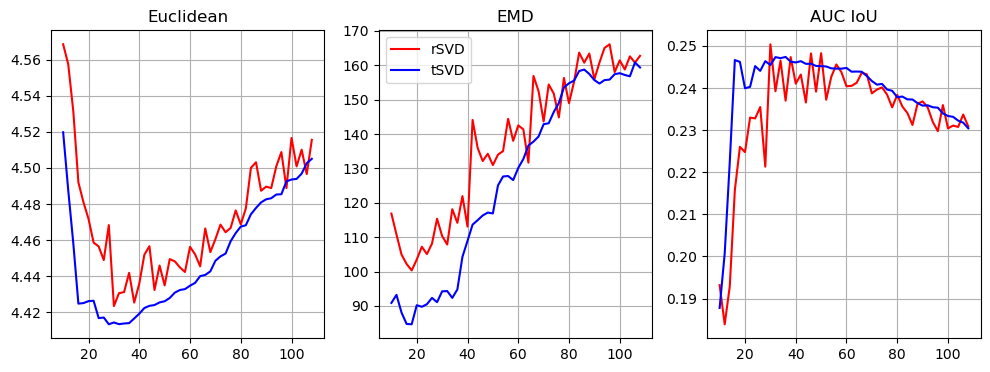

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.plot(results.k, results.rsvd_euclidean, c='r')
ax2.plot(results.k, results.rsvd_emd, c='r', label='rSVD')
ax3.plot(results.k, results.rsvd_auc_iou, c='r')

ax1.plot(results.k, results.tsvd_euclidean, c='b')
ax2.plot(results.k, results.tsvd_emd, c='b', label='tSVD')
ax3.plot(results.k, results.tsvd_auc_iou, c='b')

ax1.set_title('Euclidean')
ax2.set_title('EMD')
ax3.set_title('AUC IoU')

ax2.legend()
ax1.grid()
ax2.grid()
ax3.grid()